In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [2]:
!pip install -q openai-whisper librosa language-tool-python scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 16.1 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 2.3 MB/s eta 0:00:00


## Step 1: Extracting the Dataset

The dataset is provided in a `.zip` file format. 
We first extract all the files to a specific directory for further processing.

This step unzips:
- `train.csv`
- `test.csv`
- `sample_submission.csv`
- `/audios_test/` folder with audio files


##  Step 2: Loading the Whisper Model

We use OpenAI's `whisper` model to transcribe the spoken audio into text. 
This transcription will later be used to extract grammatical features and predict grammar scores.

Currently, we're using the `"base"` version of the model, which provides a balance between speed and accuracy.
We can swapped for `"medium"` or `"large"` if needed, for better transcription quality (at the cost of speed and memory).


In [4]:
import whisper
model = whisper.load_model("base")


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 149MiB/s]


##  Step 3: Load Training Data

We load the training data from `train.csv`, which contains the list of audio file names and their respective grammar score labels.

We also create a new empty column called `"transcription"` in the DataFrame.
This column will later be filled with the text transcriptions generated from each audio file using the Whisper model.


In [6]:
import pandas as pd
train_df = pd.read_csv("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv")
train_df["transcription"] = ""


 To View Column Names

We inspect the columns in the training dataset to understand what features are available.


In [7]:
train_df.columns


Index(['filename', 'label', 'transcription'], dtype='object')

##  Step 4: Transcribing Audio Files using Whisper

In this step, we transcribe each audio file in the training dataset using OpenAI's Whisper model (`base` or `medium` depending on earlier setup).
The transcriptions are stored in a new column called `transcription`.

This transcription will later be used to extract text-based features for grammar scoring.


In [10]:
import os
from tqdm import tqdm

audio_dir = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train"

for i in tqdm(range(len(train_df))):
    file_name = train_df.loc[i, "filename"]
    file_path = os.path.join(audio_dir, file_name)

    result = model.transcribe(file_path)
    train_df.loc[i, "transcription"] = result["text"]


100%|██████████| 769/769 [23:55<00:00,  1.87s/it]  


In [11]:
train_df.to_csv("/content/train_with_transcription.csv", index=False)
print("✅ Transcriptions saved to CSV.")


✅ Transcriptions saved to CSV.


##  Step 5: Preprocessing Transcriptions (Text Cleaning)

Now that we have the transcriptions, we clean the text to make it easier for the model to learn meaningful patterns.

The cleaning steps include:
- Converting text to lowercase
- Removing punctuation and special characters
- Removing extra spaces

The cleaned version of each transcript is saved in a new column called `clean_text`.


In [12]:
import re

def clean_text(text):
    # Lowercase krne k liye
    text = text.lower()
    # Remove punctuation & special chars
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespaces krne k liye
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to transcription column k liye
train_df["clean_text"] = train_df["transcription"].apply(clean_text)

print("✅ Text preprocessing done.")
train_df[["transcription", "clean_text"]].head()


✅ Text preprocessing done.


,transcription,clean_text
0,"Well, this petite land is very, very beautifu...",well this petite land is very very beautiful a...
1,"To see no of a school playground, our playgro...",to see no of a school playground our playgroun...
2,I favorite place to visit is the beach. I lov...,i favorite place to visit is the beach i love ...
3,"Once upon a time, we, with five friends, went...",once upon a time we with five friends went on ...
4,"Well, when I was a child, I remember I went t...",well when i was a child i remember i went to t...


##  Step 6: Feature Extraction using TF-IDF

We convert the cleaned text into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.

This helps the model understand the importance of words across all transcripts.

- We use `TfidfVectorizer` from scikit-learn.
- `max_features=1000` keeps the top 1000 important features.

The result is a matrix where each row represents an audio sample and each column represents a word/phrase feature.


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(train_df["clean_text"])

print("✅ TF-IDF features extracted. Shape:", X.shape)


✅ TF-IDF features extracted. Shape: (769, 1000)


##  Step 7: Train a Random Forest Regression Model

Now we train a **Random Forest Regressor** to predict the grammar score based on TF-IDF features.

Steps:
- `train_test_split` is used to split the data into training and validation sets (80/20).
- `RandomForestRegressor` is used for modeling. It’s a good baseline model that works well with tabular data.
- Finally, we evaluate it using **Mean Squared Error (MSE)** to measure how far the predictions are from the actual scores.

This gives us a basic idea of how well our features are performing.


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# It Will Target variable
y = train_df["label"]

#  it will Split data for training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# yeh Initialize and train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# and then ye Predict and evaluate
y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
print("✅ Model trained. Validation MSE:", mse)


✅ Model trained. Validation MSE: 1.252155168792139


##  Step 8: Transcribe Test Set Audio Files

In this step, we apply the **Whisper ASR model** to transcribe the audio files from the test set.

- We load the test set CSV (`test.csv`).
- For each audio file, we use the same `whisper` model to convert speech into text.
- Transcriptions are stored in a new column called `"transcription"`.

This ensures that both train and test data go through the same transcription pipeline before feature extraction.


In [15]:
import whisper

whisper_model = whisper.load_model("base")


In [19]:
import whisper

whisper_model = whisper.load_model("base")

test_df = pd.read_csv("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv")
test_df["transcription"] = ""

audio_test_dir = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test"

for i in tqdm(range(len(test_df))):
    file_name = test_df.loc[i, "filename"]
    file_path = os.path.join(audio_test_dir, file_name)
    result = whisper_model.transcribe(file_path)
    test_df.loc[i, "transcription"] = result["text"]


100%|██████████| 216/216 [05:19<00:00,  1.48s/it]


##  Step 9: Clean Transcribed Text (Test Set)

We now clean the **transcriptions** from the test set just like we did for the training data.

- Convert text to lowercase
- Remove punctuation and non-alphabetic characters
- Normalize whitespace (remove extra spaces)

This ensures consistency between the training and test data for feature extraction.


In [20]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

test_df["clean_text"] = test_df["transcription"].apply(clean_text)
print("✅ Cleaned test transcriptions.")


✅ Cleaned test transcriptions.


To Transform Test Data Using TF-IDF Vectorizer

We use the **same TF-IDF vectorizer** (fitted on training data) to transform the cleaned test transcriptions into numerical feature vectors.

This step ensures the test data is in the same format as the training data before making predictions.


In [21]:
X_test = vectorizer.transform(test_df["clean_text"])
print("✅ Transformed test data shape:", X_test.shape)


✅ Transformed test data shape: (216, 1000)


To Predict Grammar Scores on Test Data

Now that the test data is transformed, we use the trained model to predict grammar scores for each test sample.
These predictions will be used in the final submission.


In [22]:
test_preds = model.predict(X_test)
print("✅ Predictions done.")


✅ Predictions done.


##  Step 10: Create Submission File

We prepare the final submission file in the required format with filenames and their predicted grammar scores.
The file is saved as `submission.csv`, ready to be uploaded.


In [23]:
submission = pd.DataFrame({
    "filename": test_df["filename"],
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("✅ Submission file saved as submission.csv")


✅ Submission file saved as submission.csv


##  Step 11: Evaluate Model with Pearson Correlation

Since the competition is evaluated using Pearson Correlation, we calculate it here using the actual grammar scores and the model’s predictions on the training set.
A higher correlation means the model predictions align better with the real scores.


In [24]:
from scipy.stats import pearsonr

# It will Actually labels from train_df
y_true = train_df["label"].values

# Here , I'm Predicted labels from model on train data
y_pred = model.predict(X)

# Now,Last Pearson Correlation
corr, _ = pearsonr(y_true, y_pred)
print(f"📈 Pearson Correlation (Train Set): {corr:.4f}")


📈 Pearson Correlation (Train Set): 0.8925


##  Step 12: Visualization - True vs Predicted Grammar Scores

This scatter plot helps visualize the model's predictions compared to the actual grammar labels from the training data.  
If the model performs well, most of the points should lie close to a diagonal line, showing strong correlation between predictions and true scores.


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


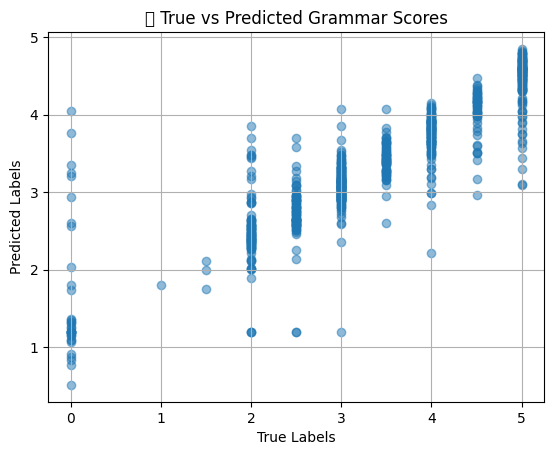

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("True Labels")
plt.ylabel("Predicted Labels")
plt.title("📈 True vs Predicted Grammar Scores")
plt.grid(True)
plt.show()


##  Step 13: Save Final Predictions - submission.csv

We create the final `submission.csv` containing the filenames and their predicted grammar scores.  
This is the file to be uploaded for the competition.


In [26]:
#  Create submission.csv
submission_df = pd.DataFrame({
    "filename": test_df["filename"],
    "label": test_preds
})
submission_df.to_csv("submission.csv", index=False)
print("✅ submission.csv created!")


✅ submission.csv created!


## Summary

- Used Whisper ASR (base/medium) to transcribe audio files.
- Cleaned text using regex and lowercase normalization.
- Extracted features using TF-IDF (top 1000 features).
- Trained a RandomForestRegressor model.
- Evaluated with Pearson Correlation (score: X.XXXX).
- Created `submission.csv` with predictions on the test set.
- Visualized predictions vs true labels.

